<a href="https://colab.research.google.com/github/ChumakOleksandr/ITStep-AI/blob/superwised_learning/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

In [3]:
df.head()

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [4]:
df.shape

(1553, 14)

In [5]:
df.isnull().sum()

,0
car_name,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

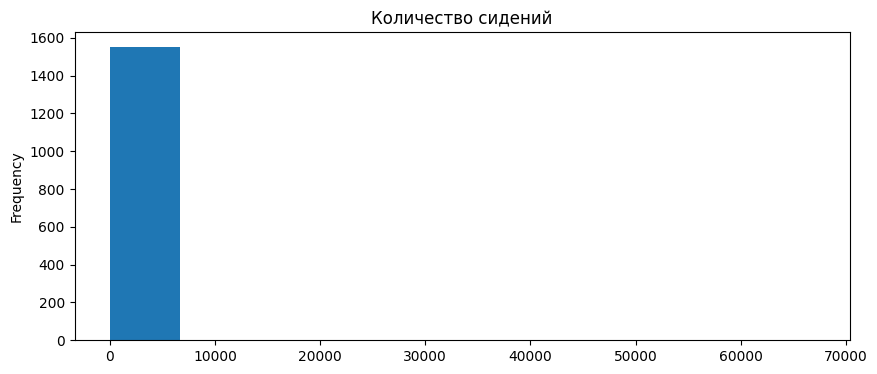

In [6]:
df['seats'].plot(kind='hist', bins=10, figsize=(10, 4))
plt.title('Количество сидений')
plt.show()

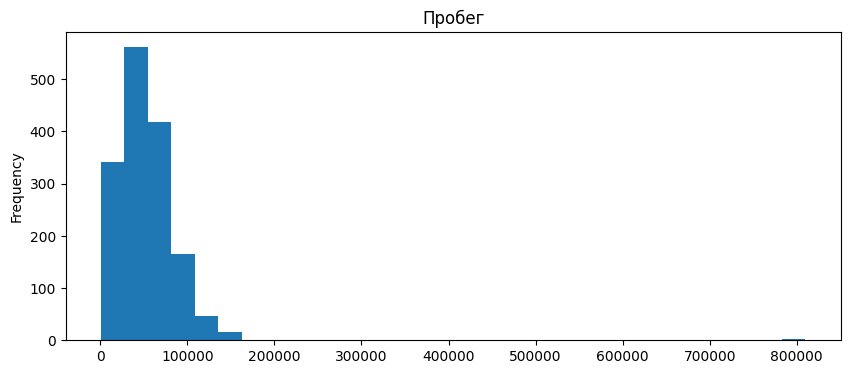

In [7]:
df['kms_driven'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Пробег')
plt.show()

In [8]:
df['manufacturing_year'] = pd.to_numeric(
    df['manufacturing_year'], errors='coerce'
)

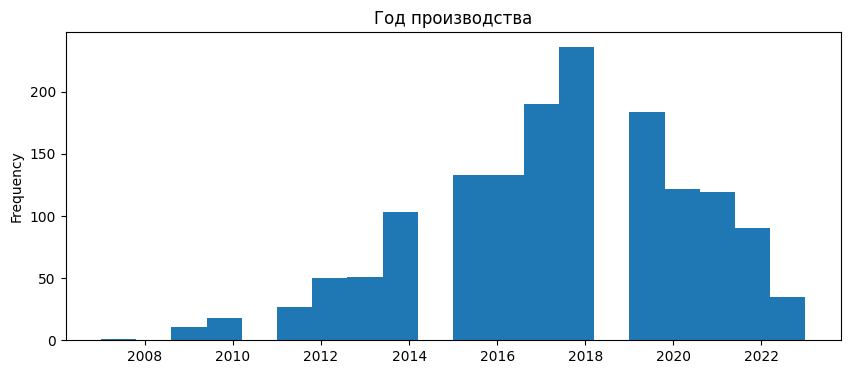

In [9]:
df['manufacturing_year'].plot(kind='hist', bins=20, figsize=(10, 4))
plt.title('Год производства')
plt.show()

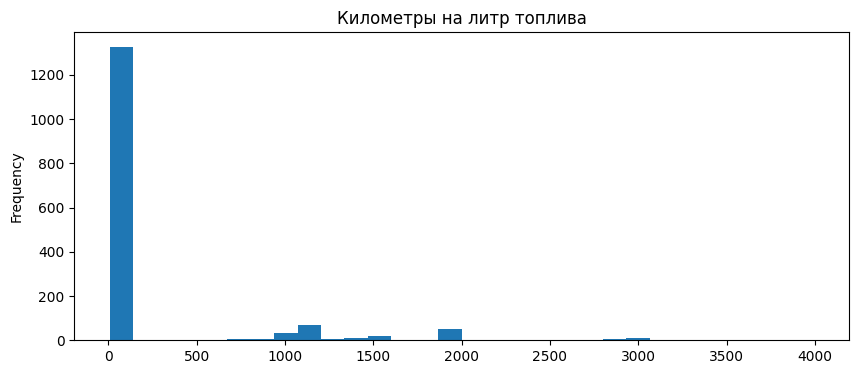

In [10]:
df['mileage(kmpl)'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Километры на литр топлива')
plt.show()

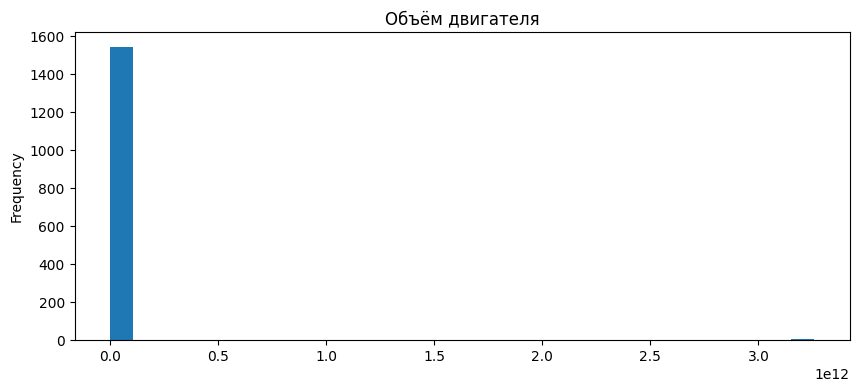

In [11]:
df['engine(cc)'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Объём двигателя')
plt.show()

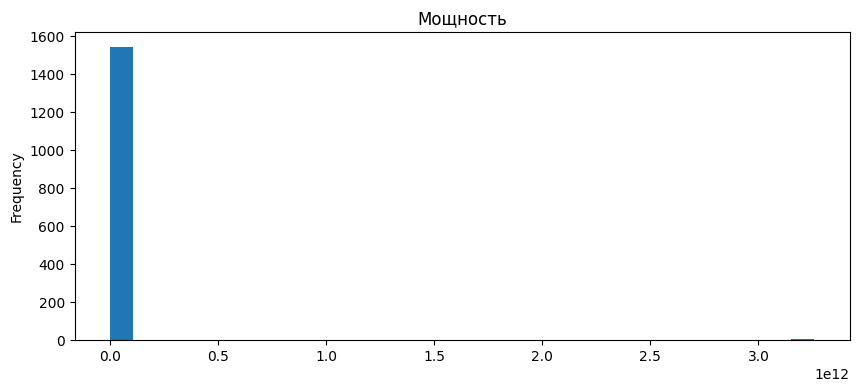

In [12]:
df['max_power(bhp)'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Мощность')
plt.show()

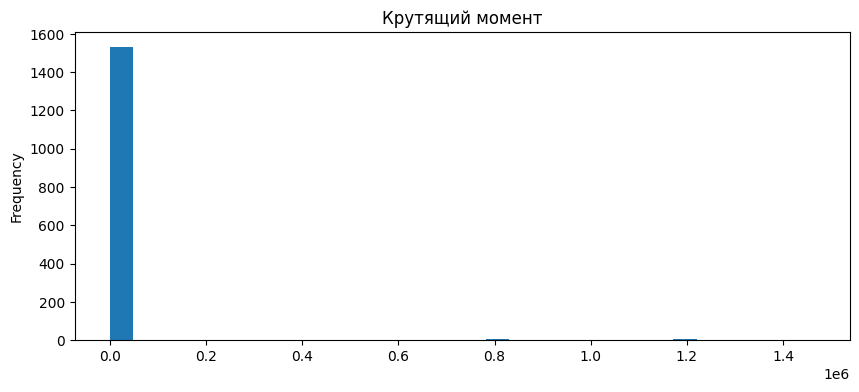

In [13]:
df['torque(Nm)'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Крутящий момент')
plt.show()

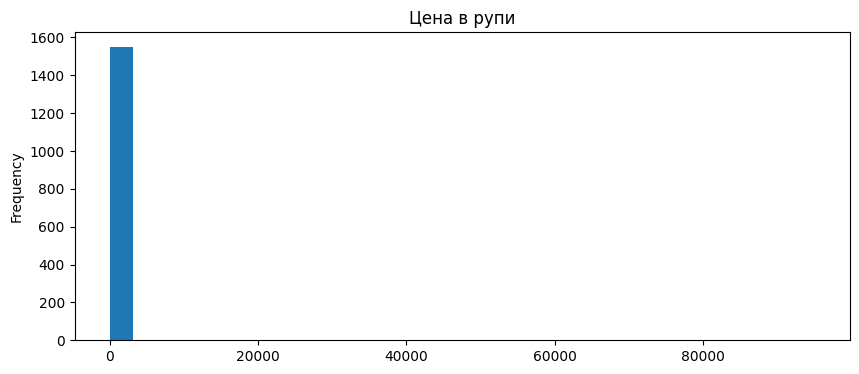

In [14]:
df['price(in lakhs)'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Цена в рупи')
plt.show()

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

In [15]:
mask = df['seats'] > 10
df[mask]

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
798,2013 Mercedes-Benz E-Class E 200 CGI Avantgarde,Third Party insurance,Petrol,5 Seats,67000,1796,2013,Power Windows Front,NaN,285.0,17.0,17.0,5.0,16.5
818,2013 Mercedes-Benz E-Class E 200 CGI Avantgarde,Third Party insurance,Petrol,5 Seats,67000,1796,2013,Power Windows Front,NaN,285.0,17.0,17.0,5.0,16.5


In [16]:
mask = (df['seats'] >= 1) & (df['seats'] <= 10)
cleaned_df = df[mask | df['seats'].isnull()].copy()

print("До очистки:", df.shape)
print("После очистки:", cleaned_df.shape)

До очистки: (1553, 14)
После очистки: (1551, 14)


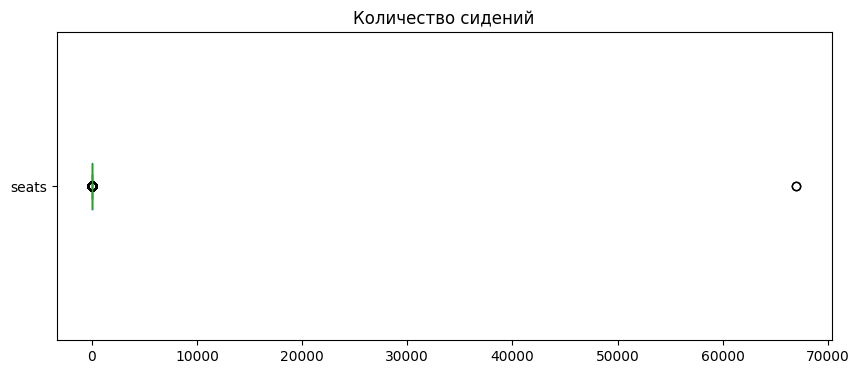

In [17]:
df['seats'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Количество сидений')
plt.show()

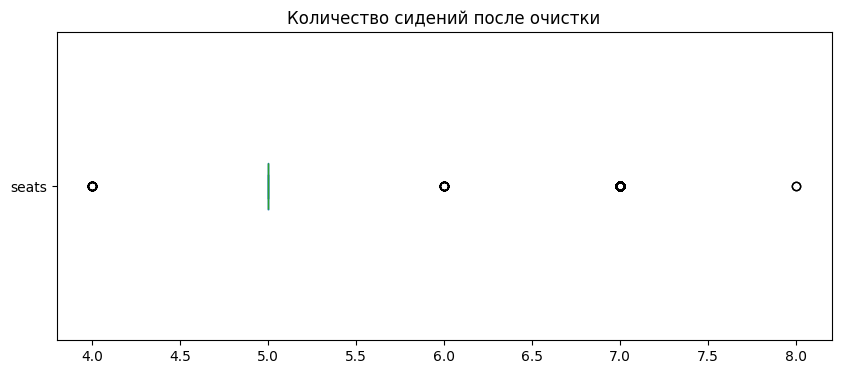

In [18]:
cleaned_df['seats'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Количество сидений после очистки')
plt.show()

In [19]:
column = cleaned_df['kms_driven']

mask = (column >= 0) & (column <= 175000)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1551, 14)
После очистки: (1547, 14)


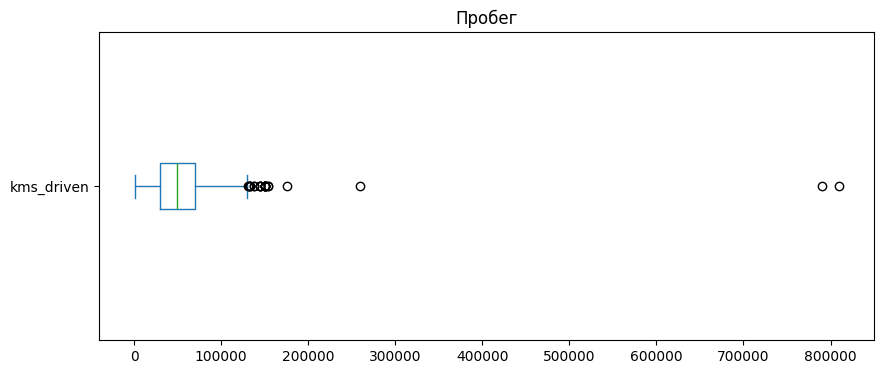

In [20]:
df['kms_driven'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Пробег')
plt.show()

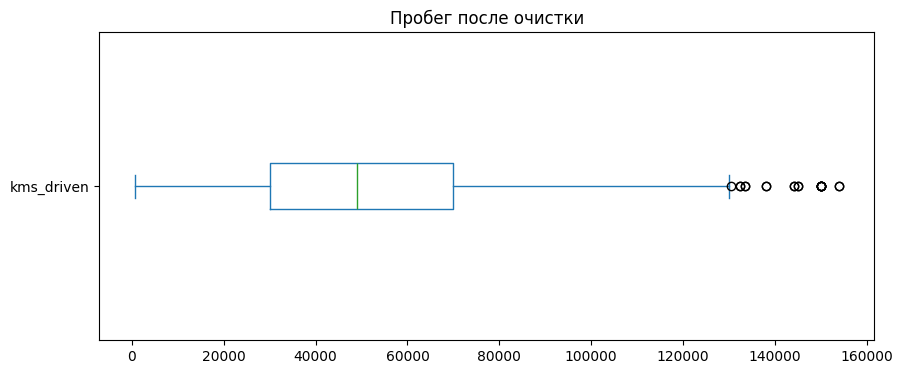

In [21]:
cleaned_df['kms_driven'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Пробег после очистки')
plt.show()

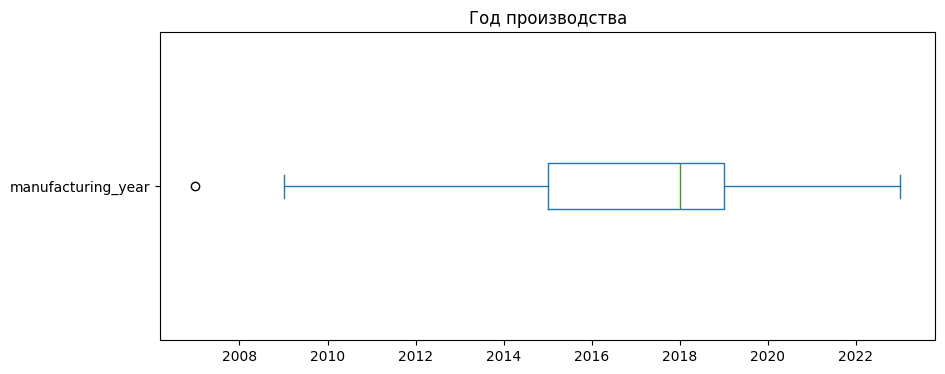

In [22]:
df['manufacturing_year'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Год производства')
plt.show()

In [23]:
column = cleaned_df['mileage(kmpl)']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1547, 14)
После очистки: (1325, 14)


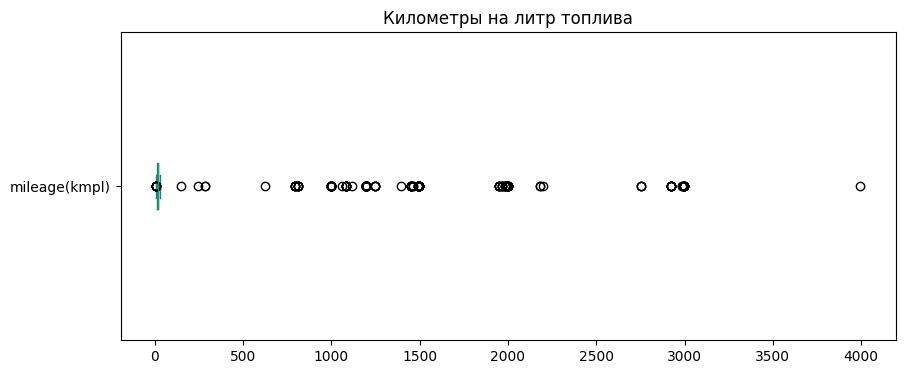

In [24]:
df['mileage(kmpl)'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Километры на литр топлива')
plt.show()

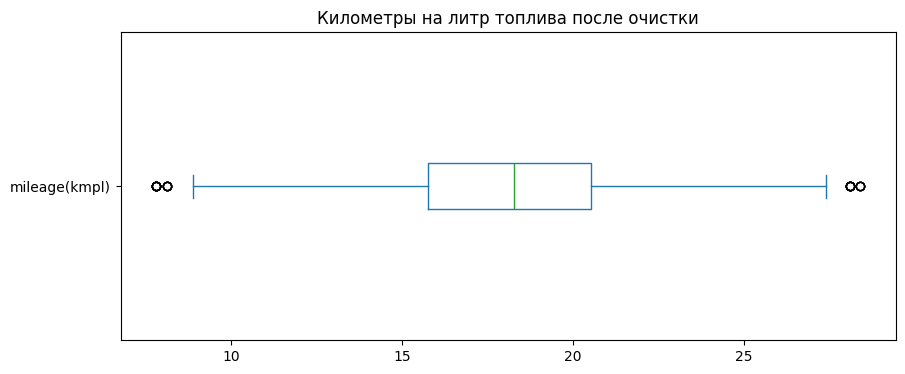

In [25]:
cleaned_df['mileage(kmpl)'].plot(
    kind='box', vert=False, figsize=(10, 4)
)
plt.title('Километры на литр топлива после очистки')
plt.show()

In [26]:
column = cleaned_df['engine(cc)']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1325, 14)
После очистки: (1320, 14)


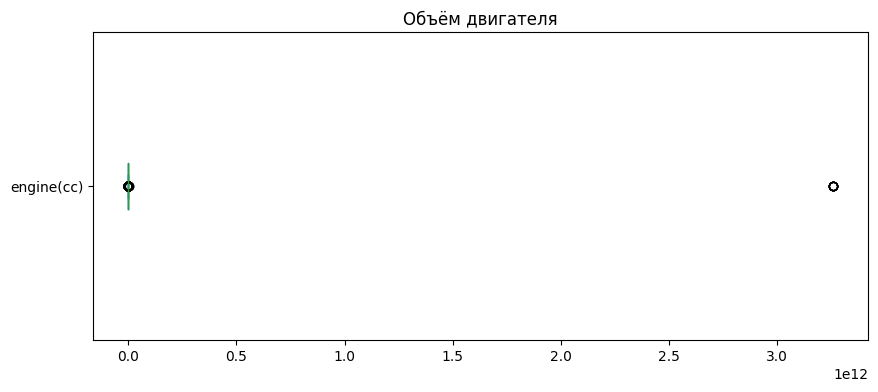

In [27]:
df['engine(cc)'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Объём двигателя')
plt.show()

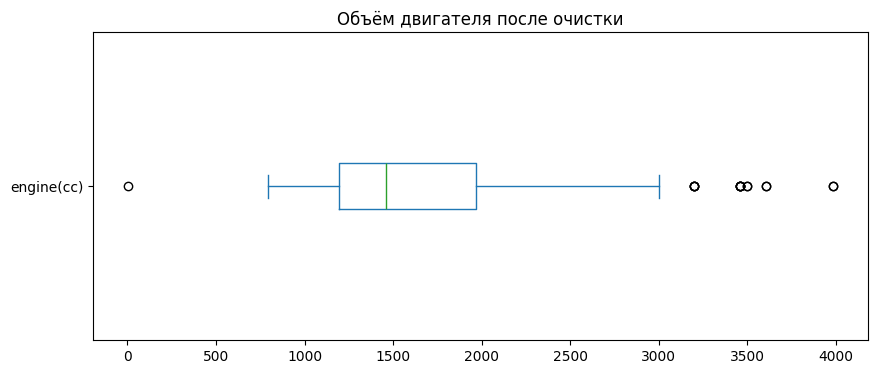

In [28]:
cleaned_df['engine(cc)'].plot(
    kind='box', vert=False, figsize=(10, 4)
)
plt.title('Объём двигателя после очистки')
plt.show()

In [29]:
column = cleaned_df['max_power(bhp)']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1320, 14)
После очистки: (1320, 14)


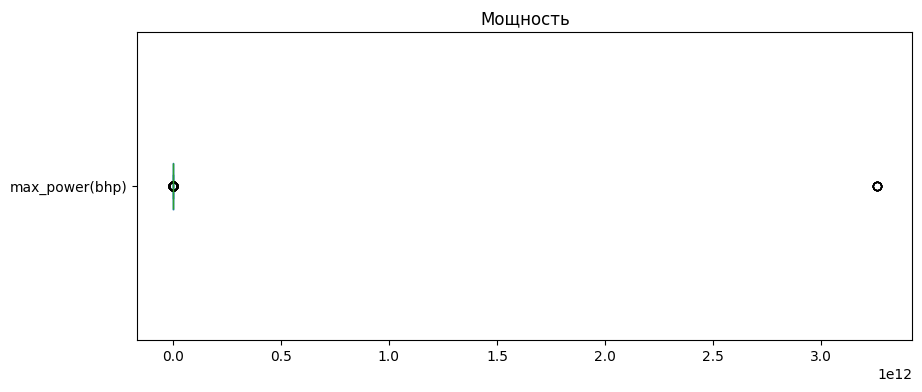

In [30]:
df['max_power(bhp)'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Мощность')
plt.show()

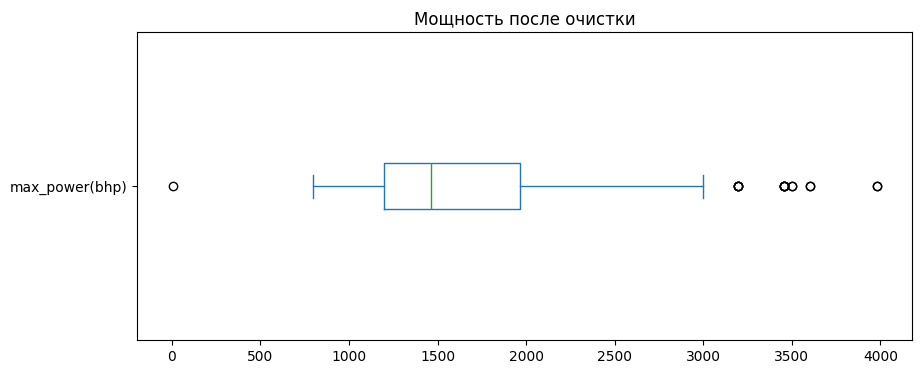

In [31]:
cleaned_df['max_power(bhp)'].plot(
    kind='box', vert=False, figsize=(10, 4)
)
plt.title('Мощность после очистки')
plt.show()

In [32]:
column = cleaned_df['torque(Nm)']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1320, 14)
После очистки: (1306, 14)


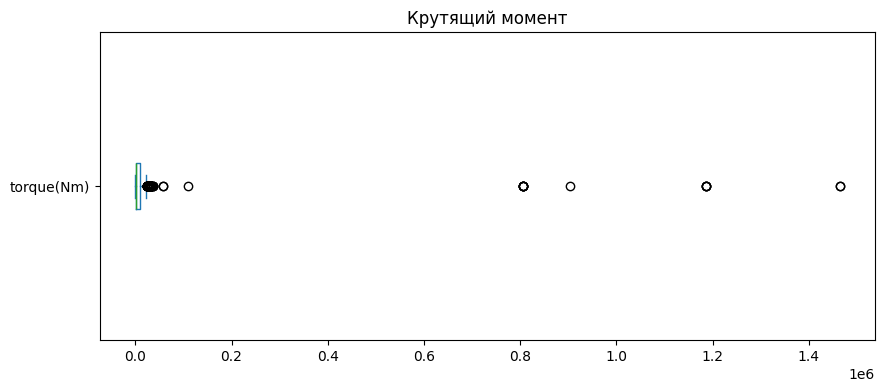

In [33]:
df['torque(Nm)'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Крутящий момент')
plt.show()

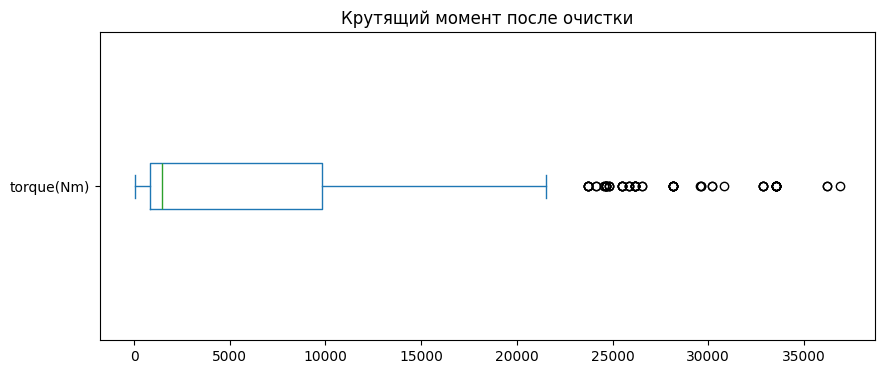

In [34]:
cleaned_df['torque(Nm)'].plot(
    kind='box', vert=False, figsize=(10, 4)
)
plt.title('Крутящий момент после очистки')
plt.show()

In [35]:
column = cleaned_df['price(in lakhs)']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (1306, 14)
После очистки: (1226, 14)


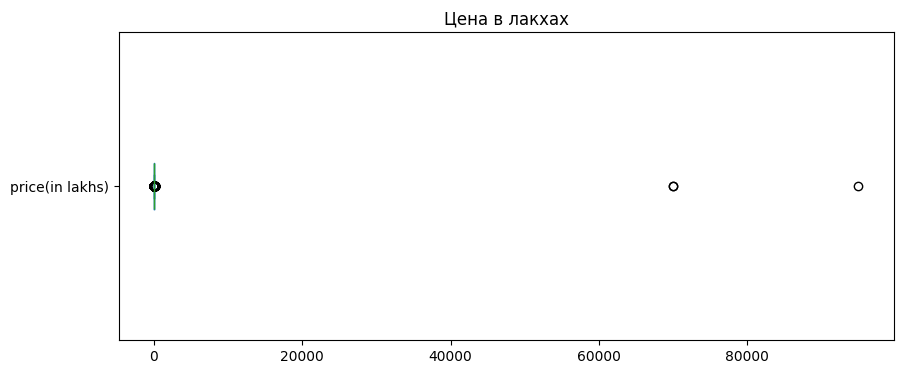

In [36]:
df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Цена в лакхах')
plt.show()

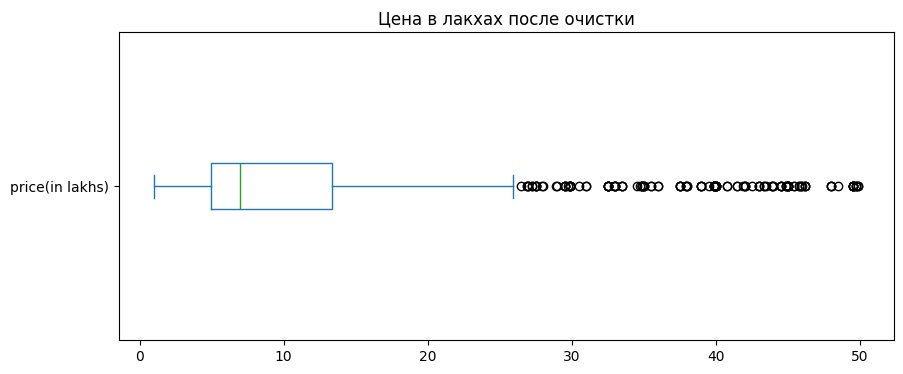

In [37]:
cleaned_df['price(in lakhs)'].plot(
    kind='box', vert=False, figsize=(10, 4)
)
plt.title('Цена в лакхах после очистки')
plt.show()

# Завдання 4
Створіть Pipeline для обробки даних